In [ ]:
import pandas as pd
from xgboost import XGBRegressor
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [4]:
df=pd.read_csv("/mnt/c/A_Class_Git/B_class_private/Exams/Exam_Class25Q2/ruc_Class25Q2_train_price.csv")

/tmp/ipykernel_9252/1245128501.py:1: DtypeWarning: Columns (3,32,34,43,46,49,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/mnt/c/A_Class_Git/B_class_private/Exams/Exam_Class25Q2/ruc_Class25Q2_train_price.csv")


In [18]:
# Create mapping dictionary for Chinese to English column names
column_mapping = {
    '城市': 'city',
    '区域': 'district',
    '板块': 'block',
    '抵押信息': 'mortgage_info',
    '年份': 'year',
    '区县': 'county',
    '板块_comm': 'block_comm',
    '容 积 率': 'floor_area_ratio',
    '停车位': 'parking_spaces',
    'coord_x': 'coord_x',
    'coord_y': 'coord_y',
    'lon': 'lon',
    'lat': 'lat',
    '交易时间': 'transaction_time'
}

# Rename columns in the dataframe
df = df.rename(columns=column_mapping)
df

,city,district,block,环线,Price,房屋户型,所在楼层,建筑面积,套内面积,房屋朝向,...,供水,供暖,供电,燃气费,供热费,parking_spaces,停车费用,coord_x,coord_y,客户反馈
0,0,109.0,150.0,二至三环,6.194049e+06,2室1厅1厨1卫,中楼层 (共5层),52.3㎡,NaN,南 北,...,民水,集中供暖,民电,2.61元/m³,30元/㎡,300.0,暂无,117.424278,40.975752,听说，设施老旧，停车费高
1,0,65.0,299.0,五至六环,4.354153e+06,3室1厅1厨1卫,顶层 (共6层),127.44㎡,123.7㎡,南 北,...,商水/民水,自采暖,商电/民电,2.61元/m³,NaN,1550.0,150,117.389228,41.091295,整体印象，网速快，面积适中
2,0,62.0,911.0,五至六环,3.321992e+06,3室2厅1厨2卫,低楼层 (共6层),118.02㎡,101.95㎡,东南,...,商水/民水,集中供暖/自采暖,商电/民电,2.61元/m³,30元/㎡,324.0,150,117.200934,40.747919,地段一般，停车划线清晰，说白了，居住体验佳
3,0,123.0,1102.0,六环外,7.895656e+06,6室3厅1厨3卫,底层 (共2层),293.23㎡,293.23㎡,东 南 西 北,...,民水,自采暖,民电,2.61-2.63元/m³,NaN,500.0,暂无,117.767308,41.228803,暖气好，平均水准，厨房设备新，不过话说，气味中性
4,0,81.0,295.0,三至四环,1.902960e+06,1房间1卫,中楼层 (共10层),39.85㎡,29.94㎡,南,...,商水/民水,集中供暖/自采暖,商电/民电,2.61-2.63元/m³,30-45元/㎡,1800.0,1200,117.334530,40.952530,可以说，通风一般，空气清新，换个角度看，气味刺鼻
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103866,11,84.0,716.0,NaN,7.903242e+05,2室2厅1厨1卫,中楼层 (共6层),93.6㎡,NaN,南 北,...,民水,集中供暖/自采暖,民电,2.68元/m³,18元/㎡,420.0,NaN,117.062762,40.513568,说句实话，家具完好，严格意义上讲，空气流通好
103867,11,84.0,716.0,NaN,1.113952e+06,3室1厅1厨1卫,低楼层 (共9层),132㎡,NaN,南,...,民水,自采暖,民电,2.68元/m³,NaN,NaN,300,117.075303,40.500796,窗户大小适中，某种意义上，陷阱条款
103868,11,84.0,716.0,NaN,7.432028e+05,3室1厅1厨1卫,中楼层 (共6层),92㎡,NaN,南 北,...,民水,集中供暖,民电,2.68元/m³,18元/㎡,NaN,NaN,117.029481,40.498825,空调噪音大，总体看，公共照明到位
103869,11,84.0,716.0,NaN,1.290376e+06,3室1厅1厨1卫,中楼层 (共17层),123㎡,NaN,南 北,...,民水,自采暖,民电,2.68元/m³,NaN,NaN,300,117.075373,40.500866,个人觉得，房屋保养好，总体上说，通勤时间中等，阳台通风佳


In [37]:
import re

def extract_area(area_str):
    if isinstance(area_str, str):
        match = re.search(r'(\d+(\.\d+)?)', area_str)
        if match:
            return float(match.group(1))
    return np.nan

df['area'] = df['建筑面积'].apply(extract_area)

In [53]:
# Convert transaction_time to datetime and calculate days since earliest transaction
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
min_date = df['transaction_time'].min()
df['days_since_start'] = (df['transaction_time'] - min_date).dt.days.astype(np.float32)/30

In [54]:
df[['days_since_start','transaction_time']]

,days_since_start,transaction_time
0,29.900000,2021-03-29
1,24.866667,2020-10-29
2,25.733334,2020-11-24
3,53.599998,2023-03-10
4,14.133333,2019-12-12
...,...,...
103866,76.133331,2025-01-14
103867,76.166664,2025-01-15
103868,76.166664,2025-01-15
103869,76.166664,2025-01-15


In [55]:
df['Price_area'] = df['Price'] / df['area']

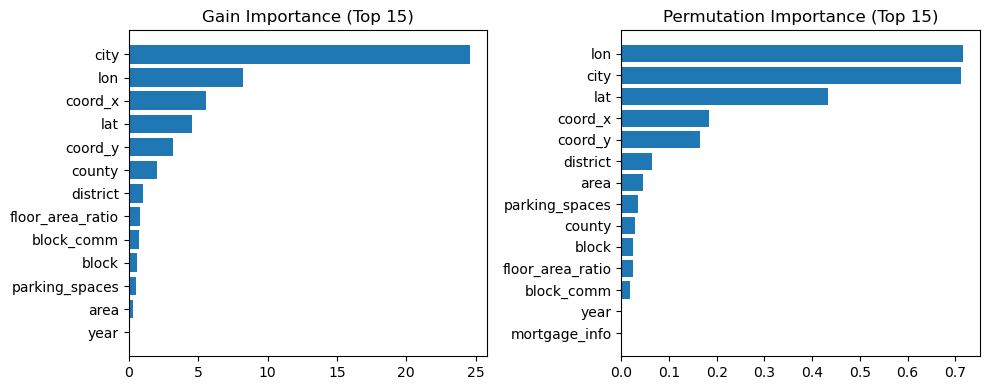

In [56]:


# Train XGBoost to predict Price, compute gain & permutation importance, PDP for top feature

import matplotlib.pyplot as plt


target='Price_area'
# Use only numeric predictors (exclude target)
numeric_features = ['city',
 'district',
 'block',
 'mortgage_info',
 'lon',
 'lat',
 #'year',
 'county',
 'block_comm',
 'floor_area_ratio',
 'parking_spaces',
 'coord_x',
 'coord_y',
 'year','area']

X = df[numeric_features].copy()
y = df[target].copy()

# Fill missing numeric values
X = X.fillna(X.median())

# Optional subsample for speed
if len(X) > 40000:
    sample_idx = np.random.RandomState(42).choice(len(X), 40000, replace=False)
    X = X.iloc[sample_idx]
    y = y.iloc[sample_idx]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    objective='reg:gamma',
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)


model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Gain-based feature importance
gain_raw = model.get_booster().get_score(importance_type='gain')
# Keys may already be original column names (e.g. '城市'), or the pattern 'f0','f1',...
if all(k.startswith('f') for k in gain_raw.keys()):
    gain_importance = {numeric_features[int(k[1:])]: v for k, v in gain_raw.items()}
else:
    gain_importance = gain_raw  # already feature names
gain_sorted = sorted(gain_importance.items(), key=lambda x: x[1], reverse=True)

# Permutation importance
perm = permutation_importance(model, X_valid, y_valid, n_repeats=5, random_state=42, n_jobs=-1)
perm_importance = dict(zip(X_valid.columns, perm.importances_mean))
perm_sorted = sorted(perm_importance.items(), key=lambda x: x[1], reverse=True)

# Select top feature by gain
top_feature = gain_sorted[0][0]

# Plot feature importances
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.barh([f for f,_ in gain_sorted[:15]][::-1],
         [v for _,v in gain_sorted[:15]][::-1])
plt.title('Gain Importance (Top 15)')
plt.subplot(1,2,2)
plt.barh([f for f,_ in perm_sorted[:15]][::-1],
         [v for _,v in perm_sorted[:15]][::-1])
plt.title('Permutation Importance (Top 15)')
plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

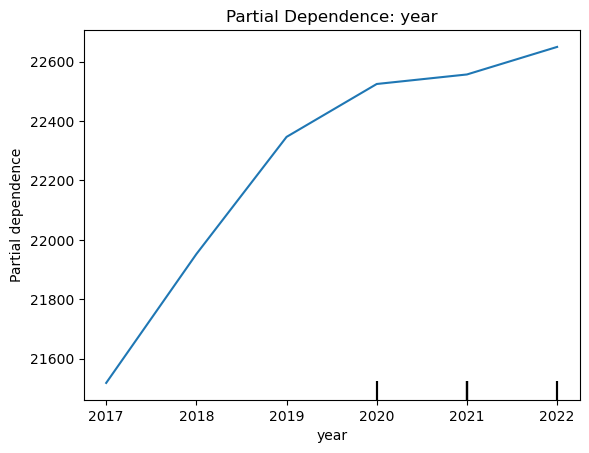

Top feature (gain): year


In [58]:
top_feature='year'
# PDP for top feature
plt.figure(figsize=(6,4))
PartialDependenceDisplay.from_estimator(model, X_valid, [top_feature], grid_resolution=60)
plt.title(f'Partial Dependence: {top_feature}')
plt.show()

print("Top feature (gain):", top_feature)

<Figure size 600x400 with 0 Axes>

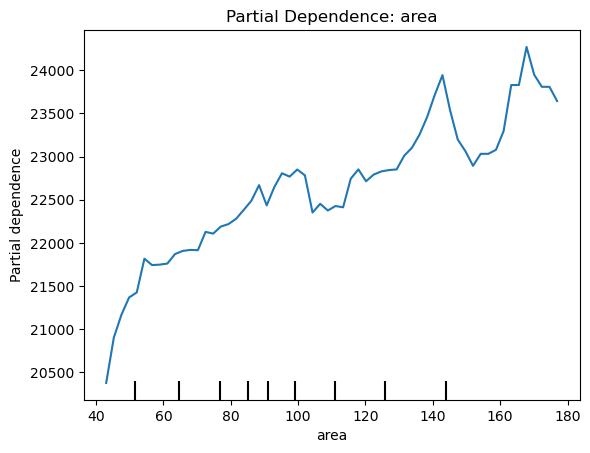

Top feature (gain): area


In [59]:
top_feature='area'
# PDP for top feature
plt.figure(figsize=(6,4))
PartialDependenceDisplay.from_estimator(model, X_valid, [top_feature], grid_resolution=60)
plt.title(f'Partial Dependence: {top_feature}')
plt.show()

print("Top feature (gain):", top_feature)